# Examiner Walkthrough — Random Forest Classification
## AI Blood Report Disease Diagnosis

This notebook explains the Random Forest workflow step by step using the project's CBC features and integer-encoded `Disease` target. Run cells from top to bottom. Keep `cleaned_data.csv` (if produced by the preprocessing notebook) or `Training.csv` in the same folder.

**Purpose:** educational machine-learning demonstration only. A high score on this dataset is not proof of clinical diagnostic performance. Before interpreting results, verify how target labels were created and investigate possible target leakage, duplicates, synthetic patterns, and class imbalance.

In [1]:
# If needed:
# %pip install pandas numpy matplotlib seaborn scikit-learn joblib

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

DATA_PATH = Path("cleaned_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Training.csv")
df = pd.read_csv(DATA_PATH)
features = ["WBC", "RBC", "HGB", "PLT", "NEUT", "LYMPH", "MONO", "EOS", "BASO"]
X = df[features]
y = df["Disease"].astype(int)
print("X:", X.shape, "y:", y.shape)
display(df.head())
display(y.value_counts().sort_index().to_frame("class_count"))


X: (299, 9) y: (299,)


,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO,Disease
0,3.7,4.90,15.6,275,1.96,1.32,0.17,0.25,0.03,3
1,7.0,5.12,13.5,386,3.33,3.05,0.53,0.09,0.06,13
2,5.0,4.67,13.3,211,2.00,2.09,0.26,0.61,0.03,11
3,6.9,4.80,15.0,224,3.77,1.75,0.58,0.70,0.05,11
4,4.2,5.31,16.0,224,2.18,1.49,0.20,0.29,0.03,3


,class_count
Disease,
0,11
1,42
2,6
3,34
4,16
5,10
6,14
7,7
8,6


## 1. Split into training and test sets
The test set is held aside for evaluation. Stratification is used only if every class has at least two examples; otherwise a standard split is used and class-level metrics may be unstable.

In [2]:
class_counts = y.value_counts()
can_stratify = len(class_counts) > 1 and class_counts.min() >= 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=40,
    stratify=y if can_stratify else None
)
print("Training records:", len(X_train), "Test records:", len(X_test))
print("Stratified split:", can_stratify)


Training records: 209 Test records: 90
Stratified split: True


## 2. How Random Forest works
A Random Forest builds many decision trees using bootstrap samples of the training data. At each split, a random subset of features is considered. For classification, each tree votes for a class and the forest returns the majority-vote class. Averaging across trees can reduce the variance of a single decision tree.

Key parameters: `n_estimators` = number of trees; `max_features` = candidate features per split; `random_state` = reproducibility; `class_weight` can account for class imbalance.

In [3]:
rf_pipeline = Pipeline(steps=[
    # Median imputation is fitted on training folds/data only.
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=40,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 3. Evaluate on held-out test data
Accuracy is the fraction of correct predictions. Balanced accuracy averages recall across classes, which is useful when class counts differ. Per-class precision, recall and F1 should be read alongside the confusion matrix. A tiny test set can make all these estimates highly uncertain.

In [4]:
y_pred = rf_pipeline.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.9444
Balanced accuracy: 0.9365
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.92      0.96        13
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         3
           6       0.75      0.75      0.75         4
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       0.80      1.00      0.89         8
          12       1.00      1.00      1.00         2
          13       0.94      0.94      0.94        32

    accuracy                           0.94        90
   macro avg       0.96      0.94      0.94        90
weighted avg       0.95      0.94    

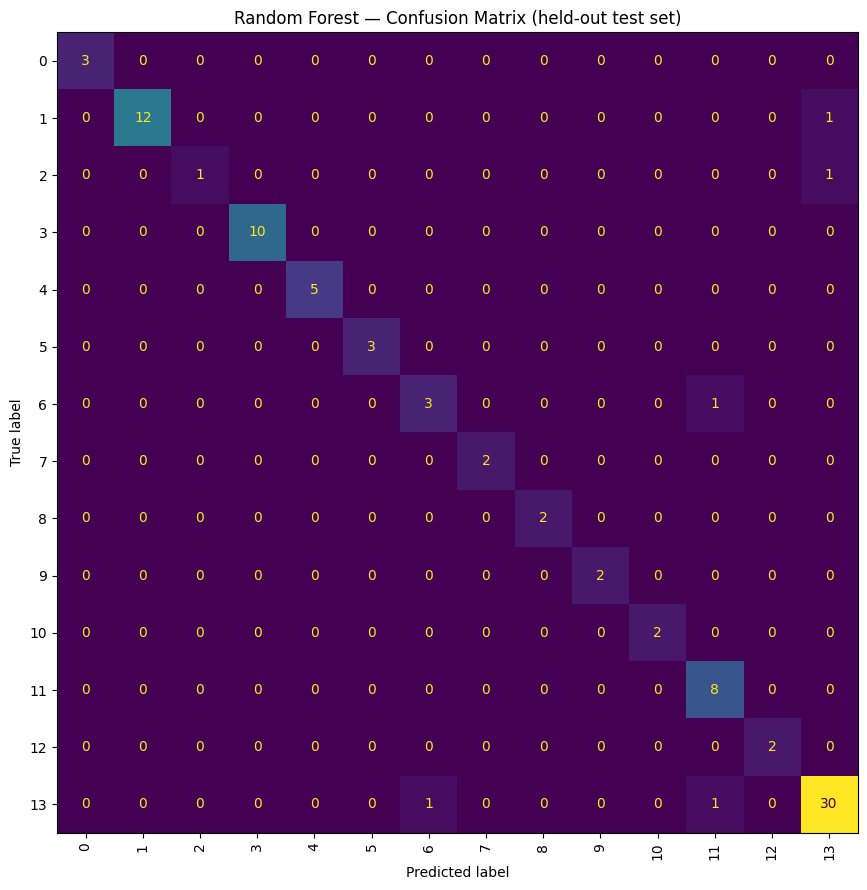

In [5]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Random Forest — Confusion Matrix (held-out test set)")
plt.tight_layout()
plt.show()


## 4. Feature importance
Random Forest impurity-based importance measures how much each feature contributes to reducing split impurity across trees. It is a model-specific association, not causation or clinical importance. Correlated features can share or distort importance.

,importance
PLT,0.161081
LYMPH,0.151653
WBC,0.140718
NEUT,0.135605
RBC,0.102493
MONO,0.083649
EOS,0.079946
HGB,0.074493
BASO,0.070363


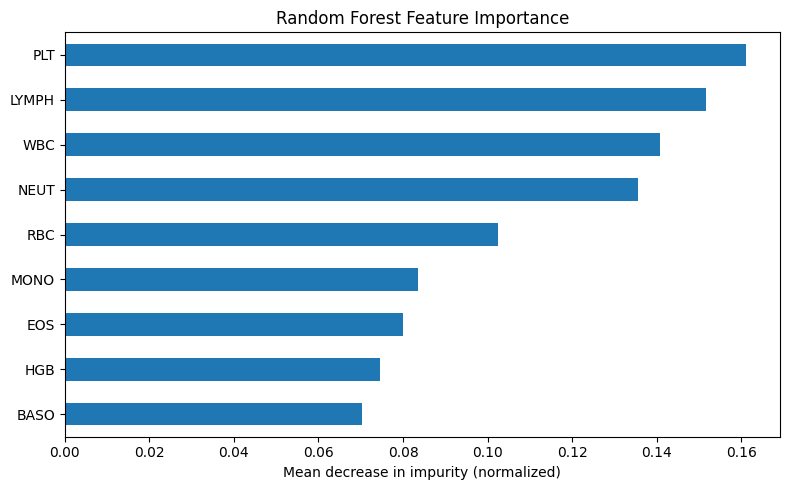

In [6]:
model = rf_pipeline.named_steps["model"]
importance = pd.Series(model.feature_importances_, index=features).sort_values()
display(importance.sort_values(ascending=False).to_frame("importance"))
importance.plot(kind="barh", figsize=(8, 5), title="Random Forest Feature Importance")
plt.xlabel("Mean decrease in impurity (normalized)")
plt.tight_layout()
plt.show()


## 5. Inspect a single tree's decision logic
The forest prediction combines many trees. One tree can be visualized to explain the kinds of threshold splits used, but it is not the entire model's logic.

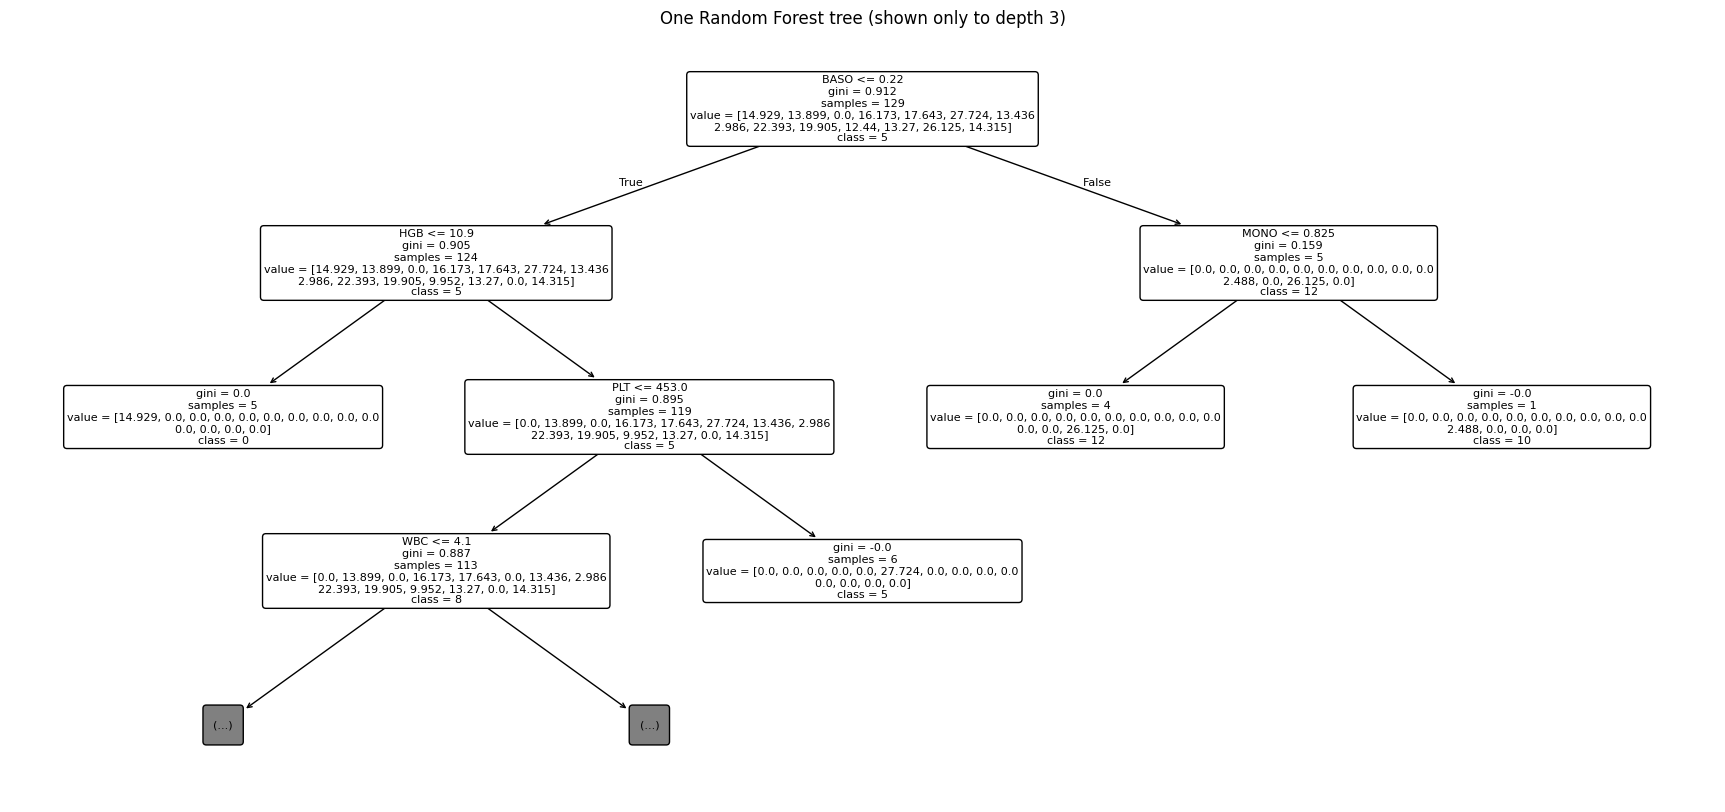

In [7]:
from sklearn.tree import plot_tree
one_tree = model.estimators_[0]
plt.figure(figsize=(22, 10))
plot_tree(one_tree, feature_names=features, class_names=[str(c) for c in model.classes_],
          filled=False, rounded=True, max_depth=3, fontsize=8)
plt.title("One Random Forest tree (shown only to depth 3)")
plt.show()


## 6. Predict one example and save model
The sample below is taken from the available feature rows for demonstration only. A prediction is a model output, not a medical diagnosis. Save the complete pipeline so the same preprocessing is applied at inference.

In [8]:
sample = X_test.iloc[[0]]
predicted_class = int(rf_pipeline.predict(sample)[0])
print("Input sample:")
display(sample)
print("Predicted Disease class ID:", predicted_class)
disease_map = {
    0: "Anemia", 1: "Polycythemia", 2: "Leukocytosis", 3: "Leukopenia",
    4: "Thrombocytopenia", 5: "Thrombocytosis", 6: "Neutropenia",
    7: "Neutrophilia", 8: "Lymphocytopenia", 9: "Lymphocytosis",
    10: "Monocytes high", 11: "Eosinophil high", 12: "Basophil high",
    13: "Normal"
}
print("Predicted label:", disease_map.get(predicted_class, "Unknown class"))
joblib.dump(rf_pipeline, "random_forest_pipeline.joblib")
print("Saved random_forest_pipeline.joblib")


Input sample:


,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO
129,6.1,4.89,15.3,154,3.79,1.95,0.13,0.18,0.03


Predicted Disease class ID: 13
Predicted label: Normal
Saved random_forest_pipeline.joblib


## 7. Inspect dataset balance and split quality

Class imbalance can make accuracy misleading. This section visualizes the target counts and checks whether the train/test split contains the classes in comparable proportions.

,All data,Train,Test
Disease,,,
0,0.036789,0.038278,0.033333
1,0.140468,0.138756,0.144444
2,0.020067,0.019139,0.022222
3,0.113712,0.114833,0.111111
4,0.053512,0.052632,0.055556
5,0.033445,0.033493,0.033333
6,0.046823,0.047847,0.044444
7,0.023411,0.023923,0.022222
8,0.020067,0.019139,0.022222


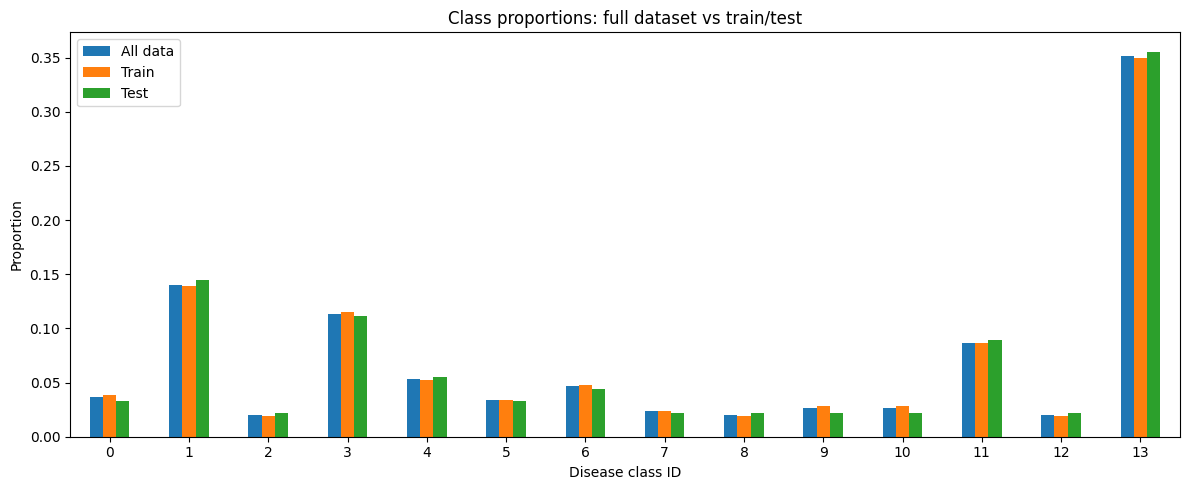

In [9]:
# Class distribution in the complete dataset and each split
distribution = pd.DataFrame({
    "All data": y.value_counts(normalize=True),
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).fillna(0).sort_index()
display(distribution)

distribution.plot(kind="bar", figsize=(12, 5))
plt.title("Class proportions: full dataset vs train/test")
plt.xlabel("Disease class ID")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Compare against a simple baseline

A baseline provides context for model performance. `DummyClassifier` predicts using a simple rule and does not learn relationships between CBC features and the target. Compare its held-out accuracy and balanced accuracy with Random Forest.

In [10]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Dummy baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Dummy baseline balanced accuracy:", round(balanced_accuracy_score(y_test, baseline_pred), 4))
print("Random Forest accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Random Forest balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))

Dummy baseline accuracy: 0.3556
Dummy baseline balanced accuracy: 0.0714
Random Forest accuracy: 0.9444
Random Forest balanced accuracy: 0.9365


## 9. Understand the model's parameters

The table describes the settings used in this notebook. `max_depth=None` means trees can grow until the stopping rules are met; the other parameters control the number and diversity of trees and the way splits are formed.

In [11]:
# Display the exact fitted pipeline settings
display(pd.Series(rf_pipeline.named_steps["model"].get_params()).to_frame("value"))

,value
bootstrap,True
ccp_alpha,0.0
class_weight,balanced
criterion,gini
max_depth,None
max_features,sqrt
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1


### Parameter experiment: tree count and depth

This small experiment compares selected configurations on the same training/test split. It is illustrative, not a substitute for cross-validation or a final untouched test set. Avoid choosing settings based on repeated inspection of the test set.

In [12]:
from sklearn.base import clone

experiments = [
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 300, "max_depth": None},
    {"n_estimators": 300, "max_depth": 5},
    {"n_estimators": 300, "max_depth": 10}
]
experiment_rows = []
for params in experiments:
    candidate = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            random_state=40,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
    candidate.fit(X_train, y_train)
    pred = candidate.predict(X_test)
    experiment_rows.append({
        **params,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred)
    })
experiment_results = pd.DataFrame(experiment_rows)
display(experiment_results)

,n_estimators,max_depth,accuracy,balanced_accuracy
0,100,NaN,0.944444,0.936470
1,300,NaN,0.944444,0.936470
2,300,5.0,0.944444,0.969952
3,300,10.0,0.944444,0.969952


## 10. Cross-validation on the training data

Cross-validation repeats training and validation across folds of the training partition. It gives a more stable view than a single split, though small datasets and repeated records can still inflate results. The held-out test set should remain untouched until final evaluation.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

fold_counts = y_train.value_counts()
if len(fold_counts) > 1 and fold_counts.min() >= 2:
    n_splits = min(5, int(fold_counts.min()))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=40)
    cv_results = cross_validate(
        rf_pipeline, X_train, y_train, cv=cv,
        scoring={"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
                 "f1_macro": "f1_macro"},
        n_jobs=-1, return_train_score=True
    )
    display(pd.DataFrame({
        "accuracy": cv_results["test_accuracy"],
        "balanced_accuracy": cv_results["test_balanced_accuracy"],
        "macro_f1": cv_results["test_f1_macro"],
        "train_accuracy": cv_results["train_accuracy"]
    }))
    print("Mean CV accuracy:", round(cv_results["test_accuracy"].mean(), 4))
    print("Mean CV balanced accuracy:", round(cv_results["test_balanced_accuracy"].mean(), 4))
else:
    print("Not enough examples in every training class for stratified cross-validation.")

,accuracy,balanced_accuracy,macro_f1,train_accuracy
0,0.905660,0.817460,0.802001,1.0
1,0.923077,0.869048,0.877976,1.0
2,0.846154,0.686508,0.662864,1.0
3,0.923077,0.930556,0.915606,1.0


Mean CV accuracy: 0.8995
Mean CV balanced accuracy: 0.8259


## 11. Hyperparameter tuning with GridSearchCV

Grid search evaluates combinations of settings using cross-validation on the training data only. It can be computationally intensive. The selected model is then evaluated once on the held-out test set.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}
min_class_count = int(y_train.value_counts().min())
if len(y_train.value_counts()) > 1 and min_class_count >= 2:
    tune_cv = min(5, min_class_count)
    search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=StratifiedKFold(n_splits=tune_cv, shuffle=True, random_state=40),
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)
    print("Best parameters:", search.best_params_)
    print("Best mean CV balanced accuracy:", round(search.best_score_, 4))
    tuned_model = search.best_estimator_
    tuned_pred = tuned_model.predict(X_test)
    print("Tuned held-out accuracy:", round(accuracy_score(y_test, tuned_pred), 4))
    print("Tuned held-out balanced accuracy:", round(balanced_accuracy_score(y_test, tuned_pred), 4))
    print(classification_report(y_test, tuned_pred, zero_division=0))
else:
    print("Tuning skipped: not enough examples per class for stratified CV.")

Best parameters: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best mean CV balanced accuracy: 0.9229
Tuned held-out accuracy: 0.9444
Tuned held-out balanced accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.92      0.96        13
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         3
           6       0.75      0.75      0.75         4
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       0.80      1.00      0.89         8
          12       0.67   

## 12. Permutation feature importance

Permutation importance measures how much a chosen score changes when one feature is shuffled. It is calculated on held-out data here, so it reflects the fitted model's reliance on each feature for this test set. Correlated features can affect interpretation; importance is not medical causation.

,feature,mean_importance,std
3,PLT,0.203242,0.015838
5,LYMPH,0.154359,0.018918
4,NEUT,0.140506,0.013435
0,WBC,0.135587,0.024998
1,RBC,0.127589,0.035221
7,EOS,0.099063,0.034493
6,MONO,0.082706,0.010521
2,HGB,0.075789,0.009461
8,BASO,0.069866,0.010707


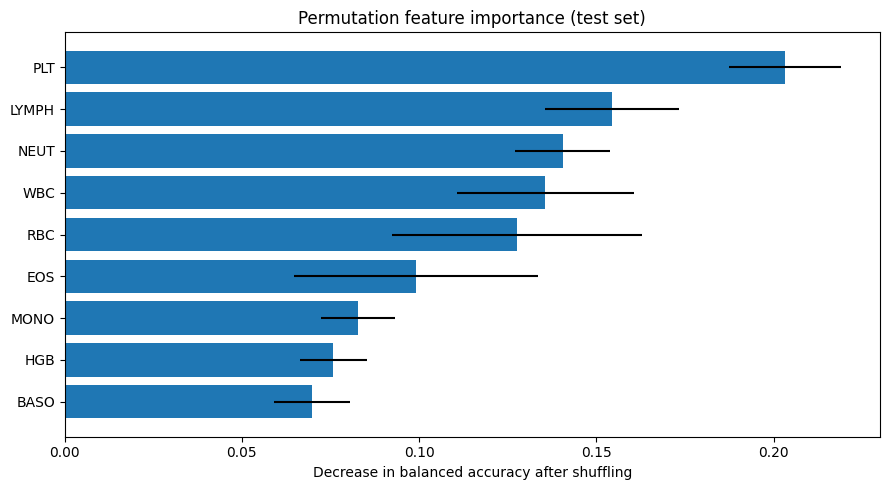

In [15]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10, random_state=40,
    scoring="balanced_accuracy", n_jobs=-1
)
perm_importance = pd.DataFrame({
    "feature": features,
    "mean_importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("mean_importance", ascending=False)
display(perm_importance)
plt.figure(figsize=(9, 5))
plt.barh(perm_importance["feature"][::-1], perm_importance["mean_importance"][::-1],
         xerr=perm_importance["std"][::-1])
plt.xlabel("Decrease in balanced accuracy after shuffling")
plt.title("Permutation feature importance (test set)")
plt.tight_layout()
plt.show()

## 13. Class probabilities and prediction confidence

`predict_proba` returns estimated class probabilities from the forest's tree votes. These values are not automatically calibrated clinical probabilities and should not be described as certainty. Review ambiguous examples and class-wise performance.

In [16]:
sample = X_test.iloc[[0]]
probabilities = rf_pipeline.predict_proba(sample)[0]
probability_table = pd.DataFrame({
    "class_id": rf_pipeline.named_steps["model"].classes_,
    "estimated_vote_fraction": probabilities
}).sort_values("estimated_vote_fraction", ascending=False)
display(sample)
display(probability_table)
print("Predicted class:", rf_pipeline.predict(sample)[0])
print("Top class vote fraction:", round(float(probability_table.iloc[0]["estimated_vote_fraction"]), 4))

,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO
129,6.1,4.89,15.3,154,3.79,1.95,0.13,0.18,0.03


,class_id,estimated_vote_fraction
13,13,0.980000
10,10,0.006667
12,12,0.003333
6,6,0.003333
4,4,0.003333
5,5,0.003333
2,2,0.000000
3,3,0.000000
0,0,0.000000
1,1,0.000000


Predicted class: 13
Top class vote fraction: 0.98


## 14. Out-of-bag (OOB) evaluation concept

With bootstrap sampling enabled, each tree leaves out some training rows. Out-of-bag scoring estimates performance using those omitted rows. It is an internal estimate, not a replacement for an independent test set. This cell fits a separate model with OOB scoring enabled.

In [17]:
oob_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300, bootstrap=True, oob_score=True,
        random_state=40, max_features="sqrt",
        class_weight="balanced", n_jobs=-1
    ))
])
oob_model.fit(X_train, y_train)
print("OOB score (accuracy):", round(oob_model.named_steps["model"].oob_score_, 4))
print("Held-out test accuracy:", round(accuracy_score(y_test, y_pred), 4))

OOB score (accuracy): 0.9187
Held-out test accuracy: 0.9444


## 15. Error analysis: inspect incorrect predictions

Looking at errors helps identify which classes the model confuses. This is a model-analysis exercise, not an interpretation of any real patient's condition.

In [18]:
error_rows = X_test.copy()
error_rows["actual_class"] = y_test
error_rows["predicted_class"] = y_pred
errors = error_rows[error_rows["actual_class"] != error_rows["predicted_class"]]
print("Incorrect predictions:", len(errors), "out of", len(X_test))
display(errors.head(20))

Incorrect predictions: 5 out of 90


,WBC,RBC,HGB,PLT,NEUT,LYMPH,MONO,EOS,BASO,actual_class,predicted_class
90,5.0,5.09,14.0,149,1.79,2.79,0.26,0.03,0.09,13,6
94,6.0,5.81,13.1,268,3.65,2.06,0.16,0.05,0.03,1,13
246,15.0,5.22,13.9,199,4.00,1.30,0.80,0.08,0.04,2,13
171,6.9,5.56,16.0,291,3.27,2.70,0.35,0.57,0.04,13,11
113,5.2,4.91,13.2,301,1.85,2.55,0.26,0.52,0.03,6,11


## 16. Learning curve: data volume vs performance

A learning curve compares training and cross-validation scores at different training-set sizes. A large gap between training and validation scores can indicate overfitting. Results can vary with small datasets.

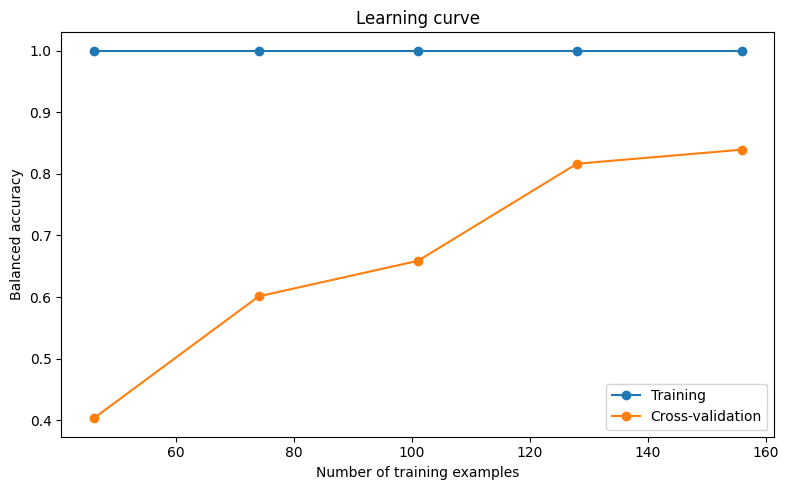

In [19]:
from sklearn.model_selection import learning_curve

if len(y_train.value_counts()) > 1 and int(y_train.value_counts().min()) >= 2:
    lc_cv = StratifiedKFold(n_splits=min(5, int(y_train.value_counts().min())),
                            shuffle=True, random_state=40)
    sizes, train_scores, valid_scores = learning_curve(
        rf_pipeline, X_train, y_train,
        train_sizes=np.linspace(0.3, 1.0, 5),
        cv=lc_cv, scoring="balanced_accuracy",
        n_jobs=-1
    )
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Training")
    plt.plot(sizes, valid_scores.mean(axis=1), marker="o", label="Cross-validation")
    plt.xlabel("Number of training examples")
    plt.ylabel("Balanced accuracy")
    plt.title("Learning curve")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Learning curve skipped: insufficient examples for stratified CV.")

## 17. Data leakage, duplicate and label-rule audit

Before presenting high accuracy, investigate whether target labels were generated directly from the same CBC features. If so, a model can reproduce label-generation rules without demonstrating independent disease detection. Also check duplicate rows and whether related records occur in both train and test partitions. For a definitive audit, consult the dataset documentation and its label-generation process.

In [20]:
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("Duplicate feature vectors:", int(X.duplicated().sum()))
print("Target class counts:")
display(y.value_counts().sort_index().to_frame("count"))

# Exact feature-vector overlap between train and test
train_keys = set(map(tuple, X_train.to_numpy()))
test_keys = set(map(tuple, X_test.to_numpy()))
print("Exact feature vectors shared across train/test:", len(train_keys.intersection(test_keys)))

print("IMPORTANT: These checks cannot prove absence of leakage.")
print("Verify whether Disease labels were derived from WBC/RBC/HGB/PLT/differential counts.")

Exact duplicate rows: 0
Duplicate feature vectors: 0
Target class counts:


,count
Disease,
0,11
1,42
2,6
3,34
4,16
5,10
6,14
7,7
8,6


Exact feature vectors shared across train/test: 0
IMPORTANT: These checks cannot prove absence of leakage.
Verify whether Disease labels were derived from WBC/RBC/HGB/PLT/differential counts.


## 18. Optional: inspect a prediction with class names

The source project uses numeric disease IDs. Confirm the mapping below against the dataset's official label documentation before presenting names; do not assume an ID-to-disease mapping is correct merely because it appears in application code.

In [21]:
# Verify this mapping against the dataset documentation before using it.
disease_map = {
    0: "Anemia", 1: "Polycythemia", 2: "Leukocytosis", 3: "Leukopenia",
    4: "Thrombocytopenia", 5: "Thrombocytosis", 6: "Neutropenia",
    7: "Neutrophilia", 8: "Lymphocytopenia", 9: "Lymphocytosis",
    10: "Monocytes high", 11: "Eosinophil high", 12: "Basophil high",
    13: "Normal"
}
predicted_id = int(rf_pipeline.predict(sample)[0])
print("Predicted class ID:", predicted_id)
print("Mapped label (verify mapping):", disease_map.get(predicted_id, "Unknown class"))

Predicted class ID: 13
Mapped label (verify mapping): Normal


## 19. Examiner viva questions and key points

1. **Why Random Forest?** It combines randomized decision trees and can model nonlinear relationships without feature scaling.
2. **What is bagging?** Each tree is trained on a bootstrap sample; predictions are aggregated.
3. **Why random feature subsets?** They diversify trees and reduce correlation between them.
4. **What does `n_estimators` do?** Sets the number of trees in the forest.
5. **What does `max_depth` do?** Limits tree depth and can help control complexity.
6. **Why use a pipeline?** Preprocessing is fitted within training data/folds and applied consistently.
7. **Why stratify the split?** It helps preserve class proportions between train and test sets.
8. **Why accuracy alone is insufficient?** It can hide poor recall on minority classes; inspect balanced accuracy, precision, recall, F1 and the confusion matrix.
9. **What is cross-validation?** Repeated training/validation over folds of the training set.
10. **What is feature importance?** A model-specific measure of reliance/impurity reduction, not causation or clinical importance.
11. **What is overfitting?** Learning patterns specific to training data that do not generalize.
12. **What is data leakage?** Information unavailable at real prediction time, or derived from the target, inadvertently enters model training/evaluation.
13. **Does a 99.8% score mean it is clinically ready?** No. It is a dataset-specific result; external, prospective and clinically governed validation would be needed.
14. **Why save the whole pipeline?** It preserves preprocessing and model steps together for consistent inference.

## 20. Final interpretation checklist

- Report the exact dataset, number of records, features, target classes, split ratio and random seed.
- Report held-out accuracy, balanced accuracy, and per-class precision/recall/F1.
- Include the confusion matrix and explain important misclassifications.
- Compare against a simple baseline and report cross-validation results.
- Record the exact model parameters and whether tuning was performed.
- Confirm class-ID mapping and label-generation rules from source documentation.
- Investigate duplicates, leakage, synthetic/templated patterns, and representativeness.
- State limitations clearly: this educational model is **not a medical diagnostic device** and must not be used to make patient-care decisions.

## Appendix — Original viva discussion points
1. Why split the data? To estimate performance on records not used for fitting.
2. Why Random Forest? It combines many randomized trees and captures nonlinear feature interactions without requiring feature scaling.
3. Why no normalization? Tree split rules are generally insensitive to monotonic feature scaling.
4. Why impute in a pipeline? The imputer learns medians from training data only, reducing data leakage.
5. What does a confusion matrix show? Correct and incorrect predictions for each class.
6. Is accuracy enough? No. Class imbalance and small class counts make balanced accuracy and per-class recall/F1 important.
7. Can this diagnose a patient? No. The dataset is small and model evaluation does not demonstrate clinical validation. It is for educational demonstration only.